<a href="https://colab.research.google.com/github/yeshaa23/Project-A-Kelompok-4-Pertamina-PBAGenap/blob/main/Notebook/3_Sentiment_labeling_leksikon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sentiment Labeling Berbasis Leksikon

## Install dan import library


In [1]:
!pip install nltk --quiet
!pip install tqdm --quiet

In [2]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from tqdm import tqdm
tqdm.pandas()

In [3]:
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab') # Add this line to check for punkt_tab
except:
    nltk.download('punkt')
    nltk.download('punkt_tab') # Add this line to download punkt_tab

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Load data hasil preprocessing BERT

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
input_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_preprocessing_bert.csv'
df = pd.read_csv(input_path)
print(f"Dataset dimuat: {len(df)} baris")

Dataset dimuat: 1883 baris


In [6]:
if 'content_cleaned_bert' not in df.columns:
    df['content_cleaned_bert'] = df['Isi Berita']

## Pelabelan Sentiment

In [7]:
# kamus leksikon sederhana
positive_words = [
    'aman','bangga','baik','bahagia','baru','berhasil','bermanfaat','bersih',
    'dukung','efisien','efektif','gratis','gembira','hebat','inovasi',
    'lancar','maju','membantu','membaik','memudahkan','meningkat',
    'nyaman','optimis','penghargaan','positif','puas','ramah','solusi',
    'sukses','terbantu','terbaik','terjangkau','cepat','untung','mudah','senang'
]

negative_words = [
    'antre','mogok','rusak','terganggu','kecelakaan','keluhan','kriminal',
    'terbakar','demo','macet','masalah','negatif','protes','ricuh',
    'salah','sulit','terlambat','tewas','buruk','celaka','curang','gagal',
    'jelek','kecewa','korban','lambat','mahal','menurun','merugi',
    'sesak','sakit','susah','tilang','aniaya','ancam','bahaya','bentrok',
    'leceh','menjerit','padat','penumpukan','vandalisme'
]

In [8]:
# fungsi pelabelan sentimen
def label_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return 'Neutral'

    words = word_tokenize(text)
    pos_score = sum(1 for w in words if w in positive_words)
    neg_score = sum(1 for w in words if w in negative_words)

    if pos_score > neg_score:
        return 'Positive'
    elif neg_score > pos_score:
        return 'Negative'
    else:
        return 'Neutral'

In [9]:
# pelabelan dengan tqdm
print("Memulai pelabelan sentimen...")
df['Sentimen_Leksikon'] = df['content_cleaned_bert'].progress_apply(label_sentiment)
print("Pelabelan selesai.")

Memulai pelabelan sentimen...


100%|██████████| 1883/1883 [00:07<00:00, 262.78it/s]

Pelabelan selesai.


## Hasil pelabelan

In [10]:
# simpan hasil
output_path = "/content/drive/MyDrive/ProjectA-PBA/hasil_sentimen_leksikon.csv"
columns_to_save = ['Link','Judul','Isi Berita','Tag','content_cleaned_bert','Sentimen','Sentimen_Leksikon']
df[columns_to_save].to_csv(output_path, index=False, encoding='utf-8')
print(f"Hasil sentimen leksikon tersimpan")

Hasil sentimen leksikon tersimpan


In [11]:
# Distribusi Sentimen
print("\nDistribusi Sentimen Leksikon:")
print(df['Sentimen_Leksikon'].value_counts())

# display 5 baris
display(df[['content_cleaned_bert','Sentimen_Leksikon']].head())


Distribusi Sentimen Leksikon:
Sentimen_Leksikon
Positive    1091
Neutral      432
Negative     360
Name: count, dtype: int64


,content_cleaned_bert,Sentimen_Leksikon
0,diskusi mengenai csr di industri pelumas berta...,Neutral
1,anak perusahaan pertamina yakni pertamina lubr...,Positive
2,— pascapencopotan dua pucuk pimpinan pertamina...,Positive
3,pertamina telah membentuk sebuah program untuk...,Positive
4,adiatma sardjito telah resmi diangkat sebagai ...,Positive


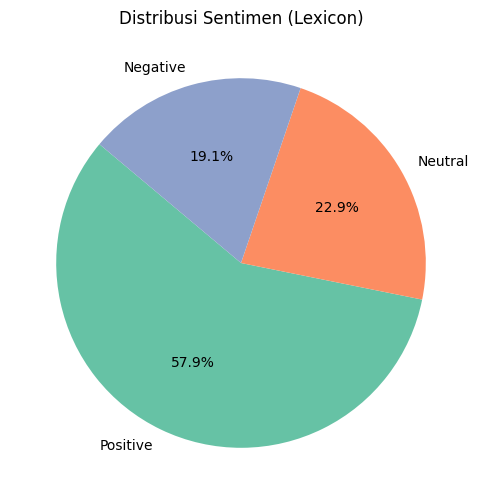

In [12]:
sentiment_counts = df['Sentimen_Leksikon'].value_counts()

plt.figure(figsize=(6,6))
colors = ['#66c2a5','#fc8d62','#8da0cb']  # hijau, oranye, biru
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Distribusi Sentimen (Lexicon)")
plt.show()